In [1]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [3]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


In [4]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [5]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [6]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

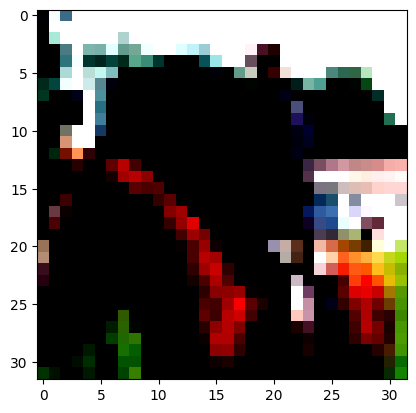

In [7]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [8]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [9]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [10]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [11]:
class Trainer:
    def __init__(self, config, transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = BasicCNN().to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            print(f'Epoch {epoch + 1} / {self.config['num_epochs']}', train_loss, val_loss, val_acc)

        test_loss, test_acc = self.test_step()
        print(f'Test loss {test_loss}, test acc {test_acc}')

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [12]:
trainer = Trainer(config, transform=transform)

In [13]:
trainer.run()

100%|██████████| 79/79 [00:03<00:00, 24.20it/s]


Epoch 1 / 10 1.7152378357256564 1.5352597432800485 45.190000000000005


100%|██████████| 79/79 [00:02<00:00, 27.68it/s]


Epoch 2 / 10 1.4370466516421625 1.368410552604289 50.33


100%|██████████| 79/79 [00:02<00:00, 30.88it/s]


...

Epoch 9 / 10 1.062948137616959 1.1791279391397405 57.709999999999994


100%|██████████| 79/79 [00:02<00:00, 31.85it/s]


Epoch 10 / 10 1.0515835704133152 1.1787585706650456 58.14


100%|██████████| 79/79 [00:02<00:00, 30.69it/s]

Test loss 1.1931362680242033, test acc 57.64


# ResNet-18

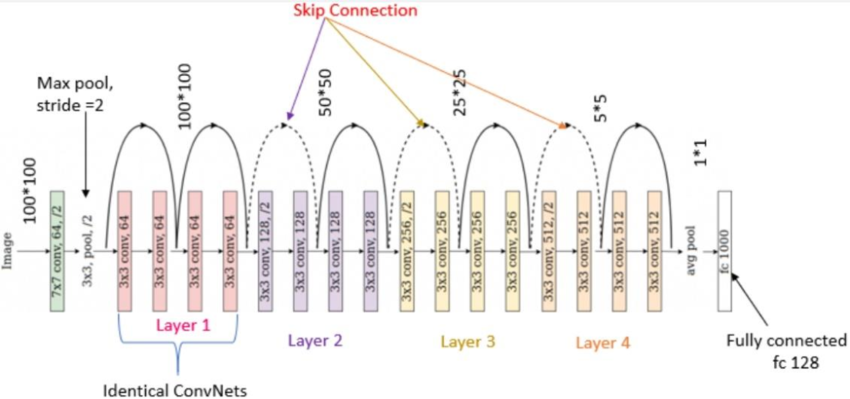

In [14]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        # Применить свертки + skip connection

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity

        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.max_poool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Сделать 4 блока
        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
      downsample = None
      if stride != 1 or self.in_channels != out_channels:
        downsample = nn.Sequential(
            nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
            nn.BatchNorm2d(out_channels),
        )

      layers = []

      layers.append(ResNetBlock(self.in_channels, out_channels, stride, downsample))
      self.in_channels = out_channels

      for _ in range(1, blocks):
          layers.append(ResNetBlock(self.in_channels, out_channels))

      return nn.Sequential(*layers)
        # ...

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.max_poool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [15]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN


In [16]:
trainer_cnn = Trainer(config, transform)
cnn_losses = []
cnn_val_accs = []
cnn_train_accs = []

for epoch in range(config['num_epochs']):
    train_loss, train_acc = trainer_cnn.train_step()
    val_loss, val_acc = trainer_cnn.val_step()

    cnn_losses.append(train_loss)
    cnn_val_accs.append(val_acc)
    cnn_train_accs.append(train_acc)

test_loss_cnn, test_acc_cnn = trainer_cnn.test_step()

100%|██████████| 79/79 [00:03<00:00, 25.03it/s]


In [17]:
trainer_resnet = Trainer(config, transform)
trainer_resnet.model = ResNet18(num_classes=10).to(trainer_resnet.device)
trainer_resnet.optimizer = Adam(trainer_resnet.model.parameters(), lr=config['lr'])

resnet_losses = []
resnet_val_accs = []
resnet_train_accs = []

for epoch in range(config['num_epochs']):
    train_loss, train_acc = trainer_resnet.train_step()
    val_loss, val_acc = trainer_resnet.val_step()

    resnet_losses.append(train_loss)
    resnet_val_accs.append(val_acc)
    resnet_train_accs.append(train_acc)

test_loss_resnet, test_acc_resnet = trainer_resnet.test_step()

100%|██████████| 313/313 [00:23<00:00, 13.10it/s]
/tmp/ipykernel_2205/1508274574.py:63: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.scheduler.step()
100%|██████████| 79/79 [00:03<00:00, 19.81it/s]


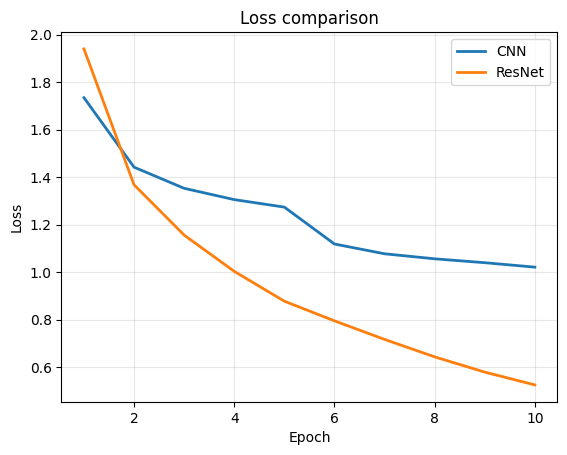

In [34]:
epochs = range(1, config['num_epochs'] + 1)
plt.plot(epochs, cnn_losses, label='CNN', linewidth=2)
plt.plot(epochs, resnet_losses, label='ResNet', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss comparison')
plt.legend()
plt.grid(True, alpha=0.3)

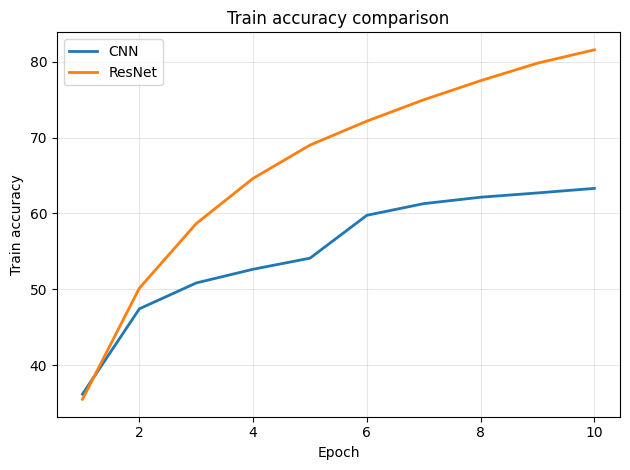

In [36]:
plt.plot(epochs, cnn_train_accs, label='CNN', linewidth=2)
plt.plot(epochs, resnet_train_accs, label='ResNet', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Train accuracy')
plt.title('Train accuracy comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

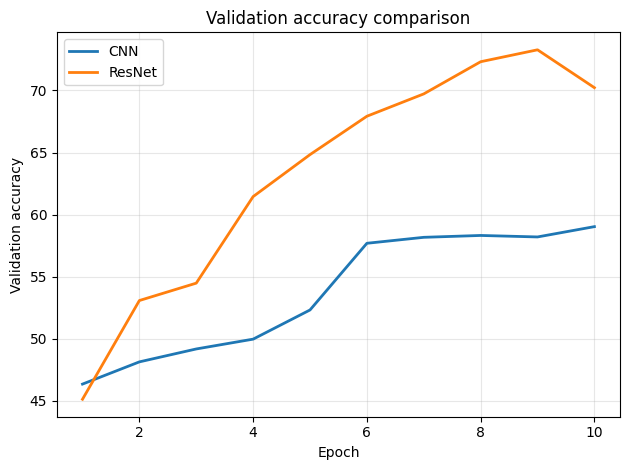

In [37]:
plt.plot(epochs, cnn_val_accs, label='CNN', linewidth=2)
plt.plot(epochs, resnet_val_accs, label='ResNet', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Validation accuracy comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Accuracy на тестовой выборке:
CNN  57.86
ResNet  70.43


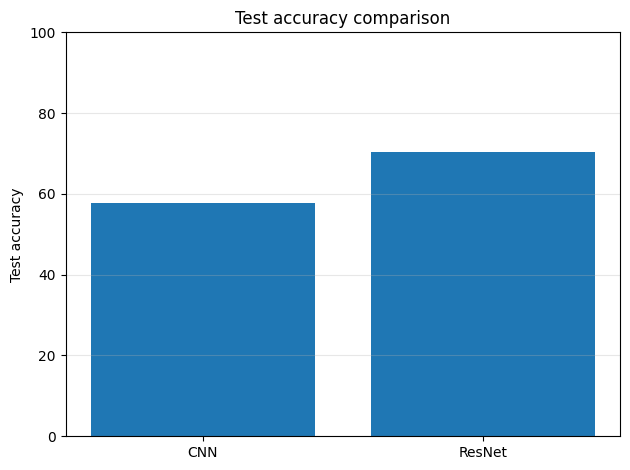

In [39]:
models = ['CNN', 'ResNet']
print("Accuracy на тестовой выборке:")
test_accs = [test_acc_cnn, test_acc_resnet]
print("CNN ", test_acc_cnn)
print("ResNet ", test_acc_resnet)
bars = plt.bar(models, test_accs)
plt.ylabel('Test accuracy')
plt.title('Test accuracy comparison')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# accuracy больше не кажется реальным словом после такого количества использований